# 05 — GT-미상 프로토콜 walkthrough: 참값 없이 결정하고, 그 결정을 채점한다

> **지위 배너 — 재현/탐색 층.** 이 노트북이 새로 계산하는 수치는 전부 **LEDGER 미등재
> (정본 아님)** 이다. 정본 수치는 [`docs/LEDGER.md`](../docs/LEDGER.md) 뿐이며, 기존 결과를
> 인용할 때는 행 id 를 병기한다. 규약: [`notebooks/README.md`](README.md).
> **무대 라벨 — 본편.** 이 권이 다루는 축 17–21 은 M8·M9 의 GT-미상 practitioner
> **본편(frontstage)** 트랙이다(GLOSSARY §8). 모든 셀은 frontstage(로그 층만)와
> backstage(reveal — committed CSV **읽기 전용**)를 구분 표기하며, `write_decision_csv`·
> `reveal()` 은 이 권에서 절대 호출하지 않는다(정본 산출물 보호). battery 는 **필요조건
> 검사(falsifier)** 다 — 통과는 무결의 증명이 아니다(축 18·CLAUDE.md §5 co-exhibit).

실무의 기본 상태에서 시작한다: **손에 있는 것은 로그와 후보 정책 분포뿐, 참값 $V(\pi_e)$ 는
아무도 모른다.** 이 권은 그 상태에서 프로토콜이 실제로 밟는 계단을 한 단씩 밟는다 —

| 섹션 | 무대 | 내용 | 정본 |
|---|---|---|---|
| A. 프로토콜 한 바퀴 | 본편 (live) | 로그 → battery·게이트·Λ\* → verdict → decision | `experiments/_practitioner.py` |
| B. battery 4-arm 손 재계산 | 본편 (live) | 각 arm 을 손으로 재계산해 `assert` 일치 | `src/ope/validity.py`·PLAN §3.5-1 |
| C. 오염 주입 미니 실연 | 본편 (live) | noised 는 즉발, calibrated 는 원리적 침묵 | 축 17·18 (`m8-17-matrix`·`m8-18-boundary`) |
| D. detection matrix 읽기 | backstage (read) | 축 17 합성 + 축 21 실데이터 replication | `17_*_matrix.csv`·`21_*_matrix.csv` |
| E. 경계와 결정 가치 | backstage (read) | 축 18(발화 0·bias 성장)·축 19(naive 대비) | `18_*_summary.csv`·`19_*_summary.csv` |
| F. 실전 카드 | 본편 (read) | 축 20 — reveal 파일이 없는 판정 | `20_*_card.csv` (`m8-20-card`) |

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists():  # notebooks/ 또는 repo 루트 어디서 실행해도 동작
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "experiments"))

from _style import apply_style

# _style 은 스크립트용으로 Agg 백엔드를 강제한다 — 노트북에서는 inline 렌더로 복원
%matplotlib inline
apply_style()
import matplotlib.pyplot as plt

TAB = ROOT / "results" / "tables"

## A. 프로토콜 한 바퀴 — 실무자의 자산만으로 (본편 · live)

`PractitionerLog` 는 **로그 층 필드만** 가진 뷰 타입이다 — oracle 필드(`v_true`·`q_true`·
`pscore_true`)는 타입 수준에서 존재하지 않는다. 합성 로그 하나(BASE_M2)를 만들되,
프로토콜에는 로그 층만 건넨다. q̂ 도 로그에서 crossfit 으로 만든다(`ope.fitters` — 실무자
가용 자원만). 산출 스키마(`DECISION_COLUMNS`)에 oracle 컬럼이 없음을 셀에서 직접 확인한다.

In [2]:
from _common import BASE_M2
from _practitioner import DECISION_COLUMNS, PractitionerLog, run_protocol

from ope.dgp import make_synthetic_bandit_data
from ope.fitters import CrossFitConfig, fit_q_hat_crossfit
from ope.validity import ValidityConfig

SEED = 700
d = make_synthetic_bandit_data(BASE_M2._replace(seed=SEED))
log = PractitionerLog(context=d.context, action=d.action, reward=d.reward,
                      pscore=d.pscore_logged, pi_log_dist=d.pi_log_dist)
q_hat = fit_q_hat_crossfit(d.context, d.action, d.reward, BASE_M2.n_actions,
                           CrossFitConfig(seed=SEED))
rows = run_protocol(log, d.pi_e_dist, axis_id="nb", scenario="walkthrough",
                    run_id=f"nb-{SEED}", seed=SEED, q_hat=q_hat,
                    cfg=ValidityConfig(seed=SEED))

for tok in ("v_true", "q_true", "pscore_true", "gt_value"):
    assert tok not in DECISION_COLUMNS  # frontstage 스키마 계약 — oracle 컬럼 부재
snips_row = next(r for r in rows if r["estimator"] == "snips")
print(f"estimator 행 {len(rows)}개 · verdict={snips_row['protocol_verdict']} · "
      f"decision={snips_row['decision']} · fragile={snips_row['fragile']}")
print(f"SNIPS = {snips_row['estimate']:.4f}  CI [{snips_row['ci_lo']:.4f}, "
      f"{snips_row['ci_hi']:.4f}]  vs incumbent mean(r) = {snips_row['incumbent_mean_r']:.4f}")

estimator 행 7개 · verdict=trust · decision=go · fragile=True
SNIPS = 0.7122  CI [0.7006, 0.7228]  vs incumbent mean(r) = 0.5927


결합·결정 규칙은 PLAN §3.5-2 에 **사전등록**돼 있다: harmonic fail → `ab_fallback` /
mean_w·placebo·disagreement fail → `distrust` / 그 외 gate v1 판정 유지. 결정 estimator 는
SNIPS(사전등록), anchor 는 같은-로그 `mean(r)`, `fragile` ⇐ Λ\*_flip < 1.5 [제안 — 라벨만].
참값은 이 계산 어디에도 등장하지 않았다 — `tests/test_practitioner_contract.py` 의 blindness
테스트는 oracle 필드를 NaN 으로 오염시켜도 산출이 동일함을 실행 수준에서 고정한다.

## B. battery 4-arm 손 재계산 (본편 · live — 02권 `assert` idiom)

battery 는 gate arm 4종의 **필요조건 검사**다(PLAN §3.5-1 — 임계 사전등록·무튜닝).
각 arm 을 정의식 그대로 손으로 재계산해 `run_validity_checks` 산출과 일치함을 검증한다.
**co-exhibit**: 이 4종 전부 기록 pscore 기반이라 marginally calibrated confounding 에는
관측 동등성으로 공동 blind 다(축 18 — §C·§E 에서 확인).

In [3]:
from ope.estimators import estimate_clipped_ips, estimate_ips, estimate_snips
from ope.validity import make_placebo_reward, run_validity_checks

cfg = ValidityConfig(seed=SEED)
rep = run_validity_checks(d.reward, d.action, d.pscore_logged, d.pi_e_dist,
                          q_hat=q_hat, context=d.context, cfg=cfg)
n, K = d.pi_e_dist.shape
idx = np.arange(n)
w = d.pi_e_dist[idx, d.action] / d.pscore_logged

# ① E[w] — HT 항등: 기록이 참 propensity 면 E[w]=1
assert np.isclose(rep.mean_w.value, w.mean(), rtol=1e-12)
# ② harmonic — T(a*) = mean(1[a=a*]/pscore), 대상은 n_a ≥ 30 인 action
t_point = np.bincount(d.action, weights=1.0 / d.pscore_logged, minlength=K) / n
n_a = np.bincount(d.action, minlength=K)
worst = max((a for a in range(K) if n_a[a] >= cfg.min_action_count),
            key=lambda a: abs(t_point[a] - 1.0))
assert np.isclose(rep.harmonic.value, t_point[worst], rtol=1e-12)
# ③ placebo — 분석가 생성 독립 noise 보상(구성상 참값 0), cfg.seed 로 결정적 재생성
eps = make_placebo_reward(d.reward, cfg)
assert np.isclose(rep.placebo.value, (w * eps).mean(), rtol=1e-12)
# ④ disagreement — weighting 계열 {IPS, SNIPS, Clipped(λ=p90(w))} 스프레드
ips = estimate_ips(d.reward, d.action, d.pscore_logged, d.pi_e_dist).value
snips = estimate_snips(d.reward, d.action, d.pscore_logged, d.pi_e_dist).value
clip = estimate_clipped_ips(d.reward, d.action, d.pscore_logged, d.pi_e_dist,
                            float(np.quantile(w, 0.90))).value
vals = (ips, snips, clip)
assert np.isclose(rep.disagreement.value,
                  (max(vals) - min(vals)) / max(abs(snips), 1e-12), rtol=1e-12)
print(f"4-arm 손 재계산 PASS — states: mean_w={rep.mean_w.state} · "
      f"harmonic={rep.harmonic.state} · placebo={rep.placebo.state} · "
      f"disagreement={rep.disagreement.state} (clean 로그 — 전부 pass 가 정상)")

4-arm 손 재계산 PASS — states: mean_w=pass · harmonic=pass · placebo=pass · disagreement=pass (clean 로그 — 전부 pass 가 정상)


fail 규칙(사전등록 verbatim): mean_w ⇔ joint-bootstrap 95% CI 가 1 제외 ∧ |E[w]−1| > 0.10 /
harmonic ⇔ 대상 action 중 CI 1 제외 ∧ |T−1| > 0.25 / placebo ⇔ CI 0 제외 /
disagreement ⇔ > 0.50 (스케일 바닥 미만이면 inconclusive). CI 는 같은 재표집 인덱스에서
estimator 7종과 battery 를 동시 계산하는 joint bootstrap(B=500·paired)이다 — 여기선 정의만
인용하고 재계산은 생략한다(§A 의 `run_protocol` 이 이미 계산했다).

## C. 오염 주입 미니 실연 — 즉발과 원리적 침묵 (본편 · live)

같은 로그에 두 가지 오염을 주입한다. ① **noised**(s=1.0 곱셈 log-normal — 축 05·17 기전):
E[w] 가 $e^{s^2/2} \approx 1.65$ 방향으로 뛰며 즉시 발화한다(축 17 실측: noised_s10 발화
1.0/1.0/1.0 — LEDGER `m8-17-matrix`). ② **calibrated**(U-주변화 기록 — 축 18 구성):
관측 동등성 세계라 **battery 전항이 원리적으로 침묵**한다 — 그런데 백스테이지 bias 는
γ=2.5 에서 −0.0732433001522501 까지 자란다(LEDGER `m8-18-boundary` verbatim — 여기서
재계산하지 않는다). 같은 검사가 한쪽에선 즉발, 한쪽에선 침묵 — 이 대비가 본편의 심장이다.

In [4]:
from ope.dgp import marginal_logging_dist

# ① noised 주입 — 즉발
z = np.random.default_rng(500_000 + SEED).normal(size=n)
ps_noised = np.clip(d.pscore_logged * np.exp(1.0 * z), 1e-6, 1.0)
rep_noised = run_validity_checks(d.reward, d.action, ps_noised, d.pi_e_dist, cfg=cfg)
print(f"noised:     E[w] = {rep_noised.mean_w.value:.3f} (예측 e^{{s²/2}} ≈ 1.649) → "
      f"state = {rep_noised.mean_w.state}")
assert rep_noised.mean_w.state == "fail" and rep_noised.mean_w.value > 1.0

# ② calibrated 주입 — 원리적 침묵 (γ=2.5 관측 동등성 세계)
cfg_conf = BASE_M2._replace(seed=SEED, confounding_strength=2.5)
d_conf = make_synthetic_bandit_data(cfg_conf)
p_marg = marginal_logging_dist(cfg_conf, d_conf.context)
ps_cal = p_marg[idx, d_conf.action]
rep_cal = run_validity_checks(d_conf.reward, d_conf.action, ps_cal, d_conf.pi_e_dist, cfg=cfg)
print(f"calibrated: E[w] = {rep_cal.mean_w.value:.4f} · checks_failed = "
      f"{rep_cal.checks_failed} (침묵 — bias 는 백스테이지에서만 보인다, m8-18-boundary)")
assert rep_cal.mean_w.state == "pass" and rep_cal.harmonic.state == "pass"

noised:     E[w] = 1.705 (예측 e^{s²/2} ≈ 1.649) → state = fail


calibrated: E[w] = 1.0034 · checks_failed = () (침묵 — bias 는 백스테이지에서만 보인다, m8-18-boundary)


## D. detection matrix 읽기 — 합성(축 17)과 실데이터 replication(축 21) (backstage · read)

여기부터는 committed CSV **읽기 전용**이다(재시뮬 0 — 04권 idiom). LEDGER 행이 인용한
값은 verbatim 일치를 검증한다(PASS 표기). **pooled confusion 은 단독 인용 금지**
(family 구성비 종속 — PLAN §3.5-3): family×arm 분리 표만 본다.

In [5]:
m17 = pd.read_csv(TAB / "17_validity_battery_matrix.csv")


def cell17(scenario, col):
    return float(m17.loc[m17["scenario"] == scenario, col].iloc[0])


# LEDGER `m8-17-matrix` verbatim 검증
assert cell17("noised_s10", "mean_w_fire") == 1.0
assert cell17("noised_s10", "harmonic_fire") == 1.0
assert cell17("noised_s10", "disagreement_fire") == 1.0
assert cell17("support_d02", "mean_w_fire") == 0.0      # 전역 통계는 침묵하고
assert cell17("support_d02", "harmonic_fire") == 1.0    # per-action 해상도가 회수한다
assert np.isclose(cell17("conf_calibrated_g25", "large_err_rate"), 0.55)
assert np.isclose(cell17("small_n_500", "harmonic_fire"), 0.275)  # 소표본 오경보 — 정직 기록
print("m8-17-matrix verbatim PASS — detectable 검출·impossible 빈칸·소표본 오경보")
m17[["family", "scenario", "mean_w_fire", "harmonic_fire", "placebo_fire",
     "disagreement_fire", "large_err_rate"]]

m8-17-matrix verbatim PASS — detectable 검출·impossible 빈칸·소표본 오경보


,family,scenario,mean_w_fire,harmonic_fire,placebo_fire,disagreement_fire,large_err_rate
0,control,clean,0.000,0.000,0.100,0.00,0.000
1,control,small_n_500,0.000,0.275,0.025,0.00,0.000
2,control,small_n_2000,0.000,0.000,0.050,0.00,0.000
3,detectable,low_overlap_b8,0.000,0.575,0.075,0.00,0.000
4,detectable,low_overlap_b16,0.325,1.000,0.150,0.05,0.325
5,detectable,support_d02,0.000,1.000,0.075,0.00,0.000
6,detectable,support_d04,1.000,1.000,0.075,0.00,0.175
7,detectable,noised_s05,1.000,0.075,0.125,0.00,0.000
8,detectable,noised_s10,1.000,1.000,0.075,1.00,0.000
9,partial,estimated_insample,0.000,0.000,0.100,0.00,0.000


In [6]:
m21 = pd.read_csv(TAB / "21_c2b_injection_matrix.csv")


def cell21(scenario, dataset, col):
    r = m21[(m21["scenario_id"] == scenario) & (m21["dataset"] == dataset)]
    return float(r[col].iloc[0])


datasets = ["optdigits", "satimage", "pendigits", "letter"]
# LEDGER `m9-21-matrix` verbatim 검증 — replication + 예상 반증
for ds in datasets:
    assert cell21("noised_s10", ds, "mean_w_fire") == 1.0       # 축 17 재현 (replication)
    assert cell21("support_d04", ds, "harmonic_fire") == 1.0    # per-action 커버 재현
    assert cell21("estimated_insample", ds, "mean_w_fire") == 1.0  # ← 사전등록 예상 반증!
print("m9-21-matrix verbatim PASS — replication 성립 + estimated 준-null 예상 반증"
      "(c2b 이중-softmax 기하는 in-sample LR 로 복원 불가 — §3.6-4 예상의 정직 반증 등재)")
m21[m21["scenario_id"].isin(["support_d04", "estimated_insample"])][
    ["scenario_id", "dataset", "mean_w_fire", "harmonic_fire", "mean_w_median",
     "large_err_rate"]]

m9-21-matrix verbatim PASS — replication 성립 + estimated 준-null 예상 반증(c2b 이중-softmax 기하는 in-sample LR 로 복원 불가 — §3.6-4 예상의 정직 반증 등재)


,scenario_id,dataset,mean_w_fire,harmonic_fire,mean_w_median,large_err_rate
20,support_d04,optdigits,0.00,1.0,0.996399,0.0
21,support_d04,satimage,0.00,1.0,0.983991,0.0
22,support_d04,pendigits,0.00,1.0,0.980968,0.0
23,support_d04,letter,0.85,1.0,0.885870,1.0
24,estimated_insample,optdigits,1.00,0.0,1.263219,0.0
25,estimated_insample,satimage,1.00,0.5,1.277568,0.0
26,estimated_insample,pendigits,1.00,0.0,1.360499,0.0
27,estimated_insample,letter,1.00,0.0,1.717571,1.0


## E. 경계와 결정 가치 — 축 18·19 (backstage · read)

**축 18(경계)**: calibration-arm 발화는 기록 모드별 0/240 인데 bias 만 자란다 — battery 는
blind spot 을 줄이지만 없애지 못한다. 유일하게 움직이는 로그-계산 신호는 Λ\*_flip 의
수축(결론이 "이유를 모른 채" 취약해진다는 보고 — 검출기 아님).
**축 19(결정 가치)**: 오염 로그에서 naive IPS 점추정은 나쁜 후보에 false-go 0.9, 프로토콜은
0.0(battery → AB 회귀) — 비용은 유예(deferral)로 명시된다.

m8-18-boundary verbatim PASS


/Users/taehyun/project/applied/ope-to-decision/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 52629 (\N{HANGUL SYLLABLE CUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/taehyun/project/applied/ope-to-decision/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/taehyun/project/applied/ope-to-decision/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/taehyun/project/applied/ope-to-decision/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 47564 (\N{HANGUL SYLLABLE MAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/taehyun/project/applied/o

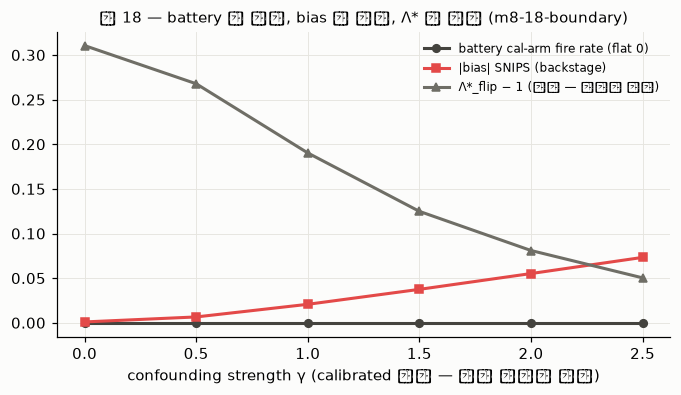

In [7]:
s18 = pd.read_csv(TAB / "18_calibrated_boundary_summary.csv")
cal = s18[s18["mode"] == "calibrated"].sort_values("gamma")
assert float(cal["cal_arm_fire_rate"].max()) == 0.0            # 발화 0/240 (calibrated)
assert np.isclose(float(cal["bias_snips"].iloc[0]), -0.0009399423509673932, rtol=1e-12)
assert np.isclose(float(cal["bias_snips"].iloc[-1]), -0.0732433001522501, rtol=1e-12)
assert round(float(cal["lam_star_med"].iloc[0]), 6) == 1.310526
assert round(float(cal["lam_star_med"].iloc[-1]), 6) == 1.050321
print("m8-18-boundary verbatim PASS")

fig, ax = plt.subplots(figsize=(7.2, 3.6))
ax.plot(cal["gamma"], cal["cal_arm_fire_rate"], marker="o", color="#44433e",
        label="battery cal-arm fire rate (flat 0)")
ax.plot(cal["gamma"], cal["bias_snips"].abs(), marker="s", color="#e34948",
        label="|bias| SNIPS (backstage)")
ax.plot(cal["gamma"], cal["lam_star_med"] - 1.0, marker="^", color="#6f6e66",
        label="Λ*_flip − 1 (수축 — 취약성 보고)")
ax.set_xlabel("confounding strength γ (calibrated 기록 — 관측 동등성 세계)")
ax.set_title("축 18 — battery 는 평평, bias 만 성장, Λ* 만 수축 (m8-18-boundary)",
             fontsize=10)
ax.legend(fontsize=8)
plt.show()

In [8]:
s19 = pd.read_csv(TAB / "19_blind_decision_summary.csv")
row = s19[(s19["regime"] == "noised") & (s19["beta_cand"] == -2.0)].iloc[0]
assert np.isclose(float(row["naive_false_go"]), 0.9)
assert float(row["proto_false_go"]) == 0.0
assert np.isclose(float(row["naive_regret_go"]), 0.20787384343961055, rtol=1e-12)
assert float(s19["proto_false_go"].max()) == 0.0 and float(s19["proto_false_stop"].max()) == 0.0
print("m8-19-decision-value verbatim PASS — naive 0.9 vs protocol 0.0 (전 셀 오류 0)")
s19[["regime", "beta_cand", "proto_go", "proto_no_go", "proto_ab",
     "naive_false_go", "proto_false_go"]]

m8-19-decision-value verbatim PASS — naive 0.9 vs protocol 0.0 (전 셀 오류 0)


,regime,beta_cand,proto_go,proto_no_go,proto_ab,naive_false_go,proto_false_go
0,healthy,-2.0,0.00,0.9,0.10,0.0,0.0
1,healthy,2.0,0.95,0.0,0.05,0.0,0.0
2,healthy,8.0,0.95,0.0,0.05,0.0,0.0
3,low_overlap,-2.0,0.00,0.0,1.00,0.0,0.0
4,low_overlap,2.0,0.00,0.0,1.00,0.0,0.0
5,low_overlap,8.0,0.00,0.2,0.80,0.0,0.0
6,noised,-2.0,0.00,0.0,1.00,0.9,0.0
7,noised,2.0,0.00,0.0,1.00,0.0,0.0
8,noised,8.0,0.00,0.0,1.00,0.0,0.0


## F. 실전 카드 — reveal 이 없는 판정 (본편 · read)

축 20 은 ZOZO 실로그 위의 1-page 판정 카드다 — **reveal 파일이 존재하지 않는다는 사실
자체가 전시물**이다(실전에서는 판정의 정오를 끝내 모른다 — 시연 프레임·검증 주장 없음).
OBD 원자료는 필요 없다: 카드 CSV(1행)가 committed 정본이다.

In [9]:
card = pd.read_csv(TAB / "20_obd_decision_card_card.csv").iloc[0]
assert card["protocol_verdict"] == "ab_fallback" and card["decision"] == "ab_test"
assert card["harmonic_state"] == "fail" and bool(card["fragile"])
assert round(float(card["harmonic_worst_t"]), 6) == 2.676554   # m8-20-card (반올림 표기)
assert not (TAB / "20_obd_decision_card_reveal.csv").exists()  # reveal 부재 — 계약
print("m8-20-card verbatim PASS · reveal 파일 부재 확인 — 이것이 실전이다")
card.to_frame("ZOZO OBD decision card (m8-20-card)")

m8-20-card verbatim PASS · reveal 파일 부재 확인 — 이것이 실전이다


,ZOZO OBD decision card (m8-20-card)
n_rounds,10000
n_actions,80
incumbent_mean_r,0.0042
time_split_gap_snips,-0.001802
ess_ratio_raw,0.034038
max_weight_raw,277.777778
support_proxy,0.0
gate_v1,distrust
mean_w,1.011109
mean_w_state,pass


### 정리 — 필요조건 검사라는 것

이 권이 밟은 계단: 로그만으로 프로토콜 한 바퀴(§A) → battery 산술의 투명성(§B) →
잡히는 오염과 원리적으로 못 잡는 오염의 대비(§C) → 그 대비의 채점표(§D 합성·실데이터
replication — 예상 반증 포함) → 경계와 결정 가치(§E) → reveal 없는 실전(§F).

**다시, 면책과 함께 닫는다**: battery 통과는 무결의 증명이 아니다. 기록 propensity 기반
신호 전부(ESS·E[w]·harmonic)는 marginally calibrated confounding 에 관측 동등성으로 공동
blind 이며(축 18 — `m8-18-boundary`), 그 몫은 Λ-감도 구간의 폭과 abstention 이 담당한다.
실데이터 주입 채점의 정본은 축 21(`m9-21-matrix` — PLAN §3.6), 프로토콜 규칙의 정본은
[`docs/PLAYBOOK.md`](../docs/PLAYBOOK.md) §2.5·§6.1 이다.